In [13]:
%load_ext autoreload
%autoreload 2

In [14]:
import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from alter_morph.hamiltonians import (
    alt_hamiltonian,
    find_m_per_state,
    find_spin_per_state,
    spectral_function,
)
from alter_morph.lattice_utilities import alter_lattice_maker

# plotting
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [15]:
def fermi_level(energies, filling):
    return np.mean(
        energies[int(filling * len(energies)) - 1 : int(filling * len(energies)) + 1]
    )

Lattice(264 vertices, 396 edges)


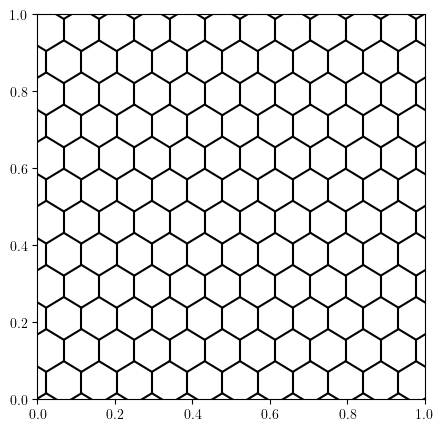

In [ ]:
# generate the lattice and set the initial conditions

import koala.graph_utils


system_length = 15
lattice_type = "voronoi"
lattice = alter_lattice_maker(system_length, lattice_type)

t1 = 1
t2 = 0.5
J = 0.1
U = J
filling = 0.2
m = np.full(lattice.n_vertices, 0)
n = np.full(lattice.n_vertices, filling * 4)
theta_offset = 0.0


fig, ax = plt.subplots(1, 1, figsize=(5, 5))
pl.plot_edges(lattice, ax=ax)
print(lattice)

In [17]:
hamiltonian = alt_hamiltonian(lattice, t1, t2, J, U, m, n, theta_offset)

energies, states = la.eigh(hamiltonian)

In [18]:
fermi_energy = fermi_level(energies, filling)

energy_to_look_at = fermi_energy
broadening = 0.5
specs = [
    spectral_function(
        lattice,
        energies,
        states,
        energy_to_look_at,
        local_operator=np.eye(4)[i],
        eta=broadening,
        n_k=50,
    )
    for i in range(4)
]

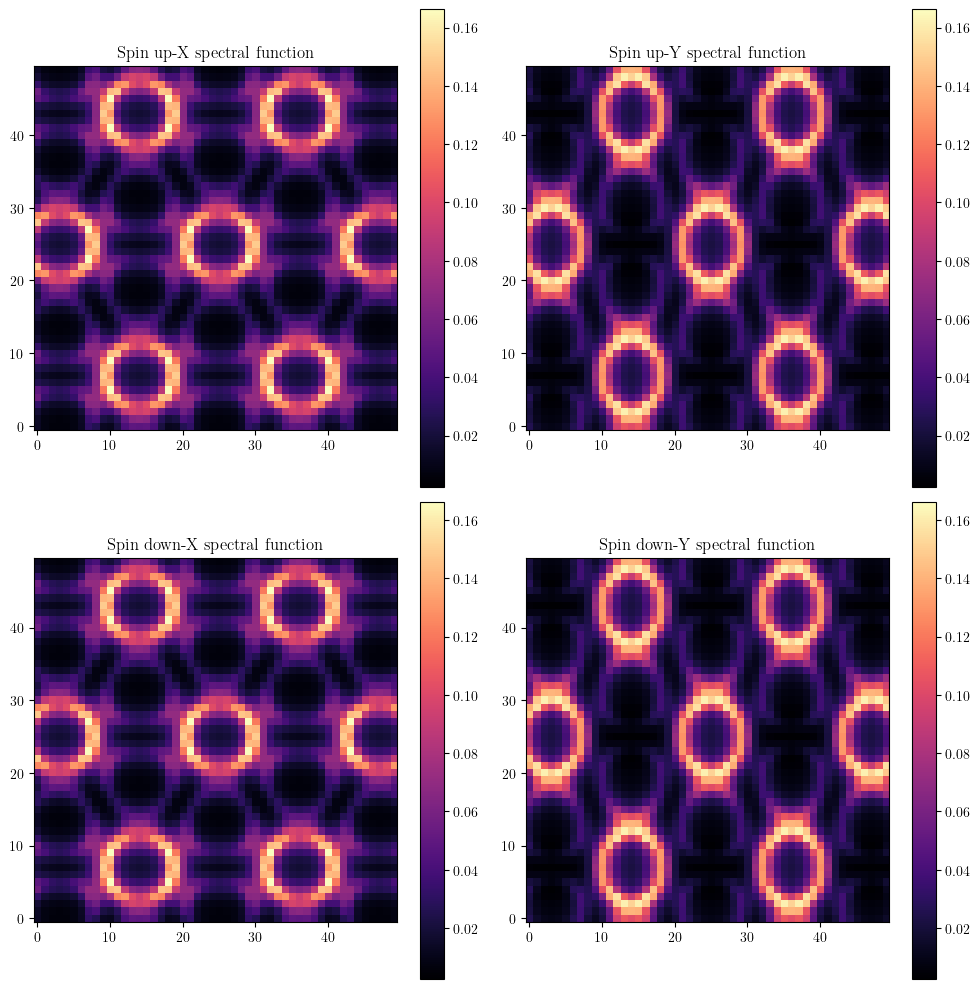

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
k_limits = 25

kx = np.arange(-k_limits, k_limits)
ky = np.arange(-k_limits, k_limits)

# log_specs = np.array([-spec.imag for spec in specs])

cmin = np.min(specs)
cmax = np.max(specs)

for n, a in enumerate(ax.flatten()):
    im = a.imshow(
        specs[n],
        cmap="magma",
        origin="lower",
        vmin=cmin,
        vmax=cmax,
    )
    # add colorbar
    plt.colorbar(im, ax=a)


ax[0, 0].set_title("Spin up-X spectral function")
ax[0, 1].set_title("Spin up-Y spectral function")
ax[1, 0].set_title("Spin down-X spectral function")
ax[1, 1].set_title("Spin down-Y spectral function")

# plt.savefig("mean_field_results.pdf")

plt.tight_layout()
plt.show()